# 04 — Deep Causal Analysis: Temporal & Co-occurrence Patterns

**Goal:** Investigate deep causal structures beyond simple frequencies.

We investigate:
1. **Co-occurring Triplets:** Which actions happen simultaneously (implicit causality: holding while cutting)?
2. **Temporal Edge Weights (Burst Durations):** Do certain triplets act as sustained actions vs fast transitional actions?
3. **Triplet Sequence Patterns (Transition Matrix):** Which triplet definitively follows another triplet in the chronologic sequence (direct causal chains).

In [1]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sys.path.insert(0, os.path.abspath('..'))
from src.temporal_analysis import build_cooccurrence_matrix, build_transition_matrix
from src.graph_builder import build_graph

sns.set_theme(style="white")

# Paths
PROJECT_ROOT = Path('..').resolve()
TRIPLET_DIR = PROJECT_ROOT / 'outputs' / 'parsed_triplets'

# Read all valid triplets
df_all = pd.read_csv(TRIPLET_DIR / 'all_triplets.csv')
df_valid = df_all[~df_all['is_null']].copy()
vid01_data = df_valid[df_valid['video'] == 'VID01']

## 1. Co-occurring Triplets (Heatmap)

Some triplets almost always appear together in multi-label frames. This implies a synchronized causal relationship (e.g., Grasper retracts cystic_plate SO THAT Hook can dissect it).

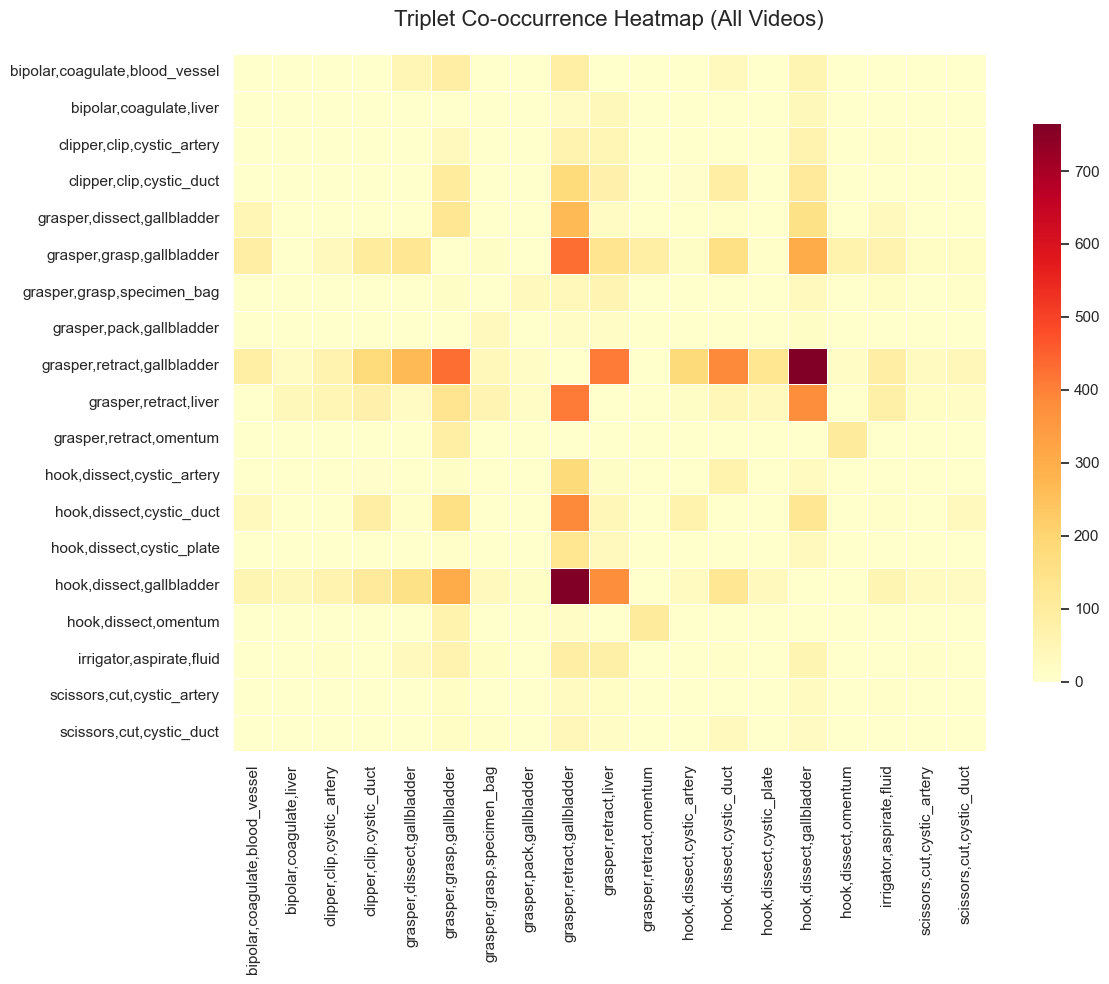

In [2]:
# Build matrix across all videos for more data
cooc_matrix = build_cooccurrence_matrix(df_valid)

# Filter down to highly active triplets to make heatmap readable
# Keep only triplets that co-occur with ANYTHING at least 50 times total
active_mask = cooc_matrix.sum(axis=1) > 50
cooc_matrix_filtered = cooc_matrix.loc[active_mask, active_mask]

if not cooc_matrix_filtered.empty:
    plt.figure(figsize=(12, 10))
    sns.heatmap(cooc_matrix_filtered, cmap="YlOrRd", annot=False, 
                linewidths=.5, cbar_kws={"shrink": .8})
    plt.title('Triplet Co-occurrence Heatmap (All Videos)', fontsize=16, pad=20)
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough co-occurrence data to plot a heatmap.")

## 2. Temporal Edge Weights (Burst Durations)

Edges in the `nx.MultiDiGraph` now contain an `avg_burst_duration` attribute.
A "burst" is the count of consecutive frames where the triplet remains active before stopping.

In [3]:
# Build the graph for VID01 (with new burst duration logic)
G_01 = build_graph(vid01_data)

burst_stats = []
for u, v, k, d in G_01.edges(data=True, keys=True):
    burst_stats.append({
        'Triplet': f"{u} → {k} → {v}",
        'Frequency (Total Frames)': d.get('frequency', 0),
        'Avg Burst Duration (Frames)': round(d.get('avg_burst_duration', 0.0), 2)
    })

df_burst = pd.DataFrame(burst_stats).sort_values('Avg Burst Duration (Frames)', ascending=False)
print("Top 10 Triplets by Average Burst Duration (Stable Actions):")
display(df_burst.head(10))

print("\nBottom 10 Triplets by Average Burst Duration (Fast Transitional Actions):")
display(df_burst[df_burst['Frequency (Total Frames)'] > 5].tail(10)) # filter out isolated noises

Top 10 Triplets by Average Burst Duration (Stable Actions):


,Triplet,Frequency (Total Frames),Avg Burst Duration (Frames)
8,hook → dissect → gallbladder,524,87.33
4,grasper → retract → liver,359,59.83
14,bipolar → coagulate → blood_vessel,100,50.00
17,clipper → clip → cystic_duct,78,39.00
7,hook → dissect → cystic_duct,21,21.00
0,grasper → grasp → gallbladder,711,20.91
18,scissors → cut → cystic_duct,17,17.00
15,bipolar → coagulate → cystic_artery,16,16.00
9,irrigator → aspirate → fluid,117,14.62
13,irrigator → retract → liver,14,14.00



Bottom 10 Triplets by Average Burst Duration (Fast Transitional Actions):


,Triplet,Frequency (Total Frames),Avg Burst Duration (Frames)
0,grasper → grasp → gallbladder,711,20.91
18,scissors → cut → cystic_duct,17,17.00
15,bipolar → coagulate → cystic_artery,16,16.00
9,irrigator → aspirate → fluid,117,14.62
13,irrigator → retract → liver,14,14.00
1,grasper → pack → gallbladder,27,13.50
5,grasper → grasp → specimen_bag,125,12.50
6,hook → coagulate → liver,9,9.00
2,grasper → retract → gallbladder,113,8.07
16,bipolar → dissect → cystic_duct,8,8.00


## 3. Triplet Sequence Patterns (Transition Matrix)

If Triplet A is active at Frame $N$, what goes active at Frame $N+1$? 
This matrix reveals chronological sequence tracking (causal workflow progression).

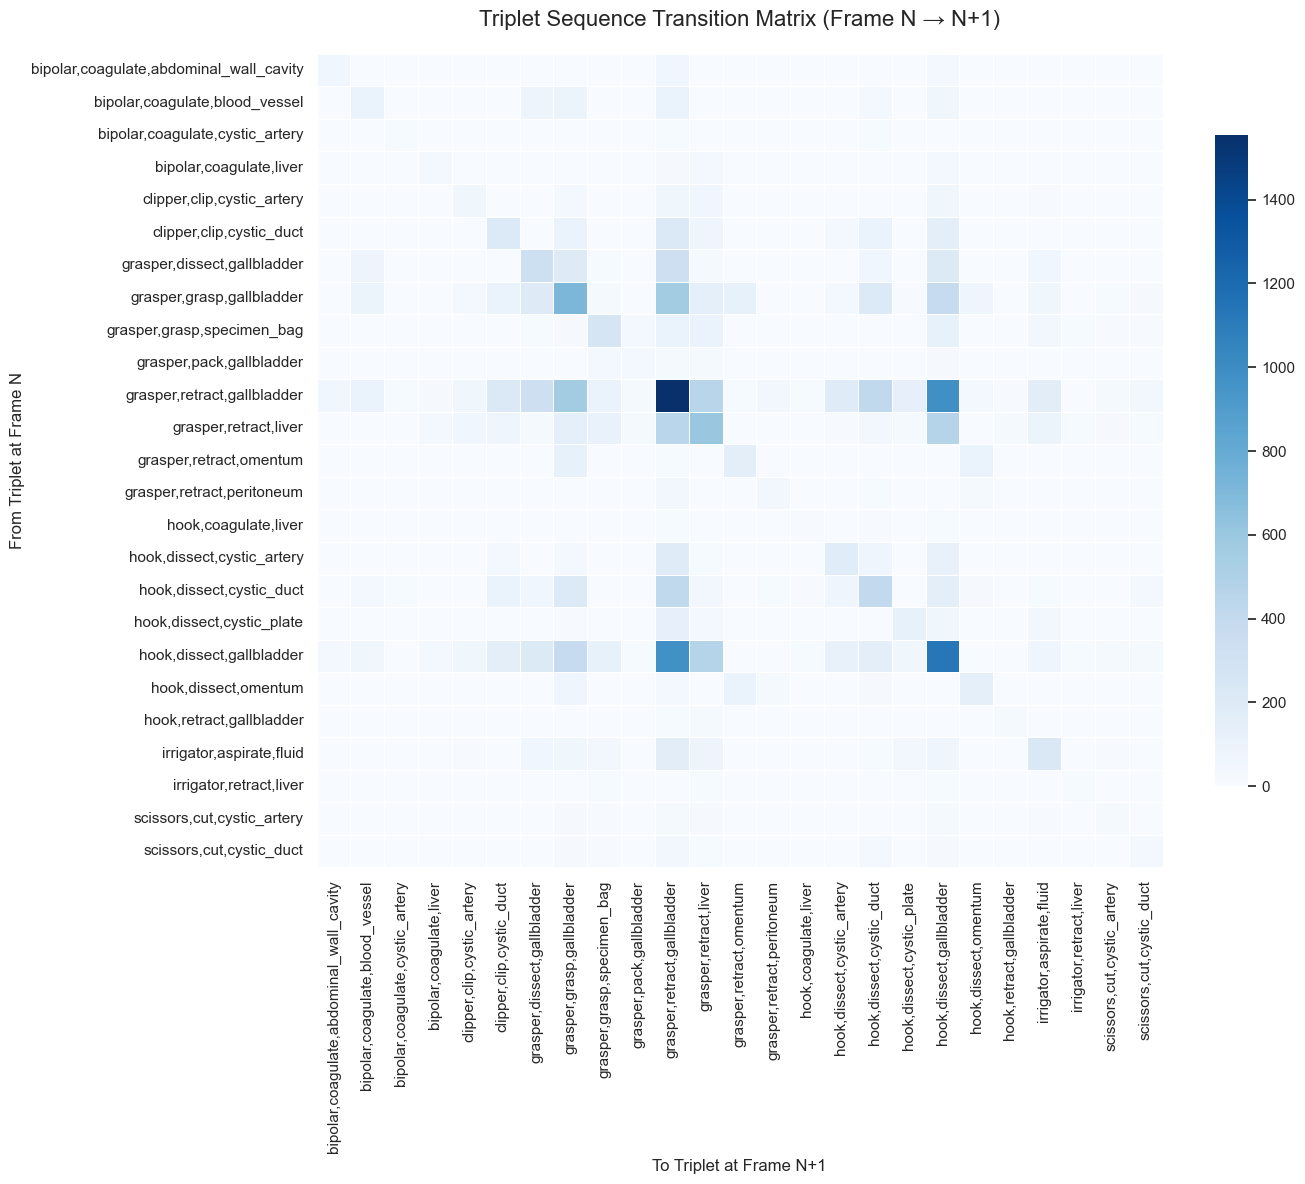

In [4]:
# Build transition matrix for all videos
trans_matrix = build_transition_matrix(df_valid, max_gap=1)

# Filter down to top active transitions 
# (only keep rows/cols where sum of transitions is > 50)
active_mask_t = (trans_matrix.sum(axis=1) > 50) | (trans_matrix.sum(axis=0) > 50)
trans_matrix_filtered = trans_matrix.loc[active_mask_t, active_mask_t]

if not trans_matrix_filtered.empty:
    plt.figure(figsize=(14, 12))
    # Note: Transition matrices are asymmetrical 
    sns.heatmap(trans_matrix_filtered, cmap="Blues", annot=False, 
                linewidths=.5, cbar_kws={"shrink": .8})
    plt.title('Triplet Sequence Transition Matrix (Frame N → N+1)', fontsize=16, pad=20)
    plt.ylabel('From Triplet at Frame N', fontsize=12)
    plt.xlabel('To Triplet at Frame N+1', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough transition data to plot a heatmap.")

### Zoom In: Transition Density
What are the highest single transition paths observed across all surgeries?

In [5]:
# Unstack and extract absolute largest single off-diagonal transitions
trans_flat = trans_matrix.unstack().reset_index(name='count')

# Filter out self-loops (A -> A)
trans_flat = trans_flat[trans_flat['From_Triplet'] != trans_flat['To_Triplet']]
trans_flat = trans_flat.sort_values('count', ascending=False)

print("Top 15 Most Frequent Sequential Triplet Transitions:")
display(trans_flat.head(15))

Top 15 Most Frequent Sequential Triplet Transitions:


,To_Triplet,From_Triplet,count
773,"hook,dissect,gallbladder","grasper,retract,gallbladder",982
485,"grasper,retract,gallbladder","hook,dissect,gallbladder",977
471,"grasper,retract,gallbladder","grasper,grasp,gallbladder",561
311,"grasper,grasp,gallbladder","grasper,retract,gallbladder",560
775,"hook,dissect,gallbladder","grasper,retract,liver",471
551,"grasper,retract,liver","hook,dissect,gallbladder",468
542,"grasper,retract,liver","grasper,retract,gallbladder",460
478,"grasper,retract,gallbladder","grasper,retract,liver",455
707,"hook,dissect,cystic_duct","grasper,retract,gallbladder",418
483,"grasper,retract,gallbladder","hook,dissect,cystic_duct",417


---
**Conclusion:** Detailed transition chains and precise co-occurrences fully document the causality in workflow deviations.